The [Street View House Numbers Dataset](https://www.openml.org/d/41081) contains 32-by-32 RGB images centered around a single digit of a house number appearing in Google Street View. Many of the images do contain some distractors at the sides. Your goal is to build a model that recognizes the correct digit. In detail, you need to do the following tasks:
1. Images come from real-world street scenes and include noise, distractors, and varying lighting. This is a multi-class classification problem with 10 output classes. Start with simple models like Logistic Regression using flattened image inputs.
2. Extend to Multi-Layer Perceptrons (MLP) to capture non-linear patterns.
3. Evaluate why these models fail due to lack of spatial feature extraction.
4. Develop Convolutional Neural Networks (CNNs) to capture spatial structure.
5. Apply preprocessing such as normalization and optional data augmentation.
6. Train using cross-entropy loss and evaluate with accuracy and confusion matrix.
7. Compare models and demonstrate performance improvements from simple to advanced architectures.

In [4]:
!pip install tensorflow-datasets -q

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ==============================
# Logistic Regression for c
# ==============================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [7]:
# ==============================
# 1. Load SVHN and Create Fixed 70/15/15 Split
# ==============================

from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow-datasets -q

import os
import numpy as np
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split

SAVE_DIR = "/content/drive/MyDrive/SVHN_data"
os.makedirs(SAVE_DIR, exist_ok=True)

RAW_DATA_PATH = f"{SAVE_DIR}/svhn_raw_data.npz"
SPLIT_DATA_PATH = f"{SAVE_DIR}/svhn_split_70_15_15.npz"

RANDOM_STATE = 42

# ==============================
# Load raw SVHN data
# ==============================

if os.path.exists(RAW_DATA_PATH):
    print("Loading raw SVHN from Google Drive...")

    raw_data = np.load(RAW_DATA_PATH)

    X_original_train = raw_data["X_train"]
    y_original_train = raw_data["y_train"]
    X_original_test = raw_data["X_test"]
    y_original_test = raw_data["y_test"]

else:
    print("Downloading SVHN for the first time...")

    ds_train, ds_test = tfds.load(
        "svhn_cropped",
        split=["train", "test"],
        as_supervised=True,
        batch_size=-1
    )

    X_original_train, y_original_train = tfds.as_numpy(ds_train)
    X_original_test, y_original_test = tfds.as_numpy(ds_test)

    np.savez_compressed(
        RAW_DATA_PATH,
        X_train=X_original_train,
        y_train=y_original_train,
        X_test=X_original_test,
        y_test=y_original_test
    )

    print("Saved raw SVHN to Google Drive.")

print("Original Train:", X_original_train.shape, y_original_train.shape)
print("Original Test:", X_original_test.shape, y_original_test.shape)

# ==============================
# Create or load fixed 70/15/15 split
# ==============================

if os.path.exists(SPLIT_DATA_PATH):
    print("Loading fixed 70/15/15 split from Google Drive...")

    split_data = np.load(SPLIT_DATA_PATH)

    X_train = split_data["X_train"]
    y_train = split_data["y_train"]

    X_val = split_data["X_val"]
    y_val = split_data["y_val"]

    X_test = split_data["X_test"]
    y_test = split_data["y_test"]

else:
    print("Creating fixed 70/15/15 split...")

    X_all = np.concatenate([X_original_train, X_original_test], axis=0)
    y_all = np.concatenate([y_original_train, y_original_test], axis=0)

    # Step 1: 70% train, 30% temporary
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all,
        y_all,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y_all
    )

    # Step 2: 15% validation, 15% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=y_temp
    )

    np.savez_compressed(
        SPLIT_DATA_PATH,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )

    print("Saved fixed 70/15/15 split to Google Drive.")

print("==============================")
print("Final Dataset Split")
print("==============================")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Total:", len(X_train) + len(X_val) + len(X_test))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.MSNBLE_3.1.0/svhn_cropped-test.tfrecord-[0-9][0-9]…

Generating extra examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.MSNBLE_3.1.0/svhn_cropped-extra.tfrecord-[0-9][0-9…

Dataset svhn_cropped downloaded and prepared to /root/tensorflow_datasets/svhn_cropped/3.1.0. Subsequent calls will reuse this data.
Saved raw SVHN to Google Drive.
Original Train: (73257, 32, 32, 3) (73257,)
Original Test: (26032, 32, 32, 3) (26032,)
Creating fixed 70/15/15 split...
Saved fixed 70/15/15 split to Google Drive.
Final Dataset Split
Train: (69502, 32, 32, 3) (69502,)
Validation: (14893, 32, 32, 3) (14893,)
Test: (14894, 32, 32, 3) (14894,)
Total: 99289


Since the input images are 32×32 RGB images, each image is flattened into a one-dimensional feature vector before being passed into the model.


In [10]:
# ==============================
# 2. Prepare DataLoader
# ==============================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Normalize + flatten: 32x32x3 -> 3072
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype("float32") / 255.0
X_val_flat = X_val.reshape(X_val.shape[0], -1).astype("float32") / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1).astype("float32") / 255.0

y_train = y_train.astype("int64")
y_val = y_val.astype("int64")
y_test = y_test.astype("int64")

train_dataset = TensorDataset(
    torch.tensor(X_train_flat),
    torch.tensor(y_train)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_flat),
    torch.tensor(y_val)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_flat),
    torch.tensor(y_test)
)

batch_size = 512

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Using device: cuda
Train images: 69502
Validation images: 14893
Test images: 14894


In [11]:
# ==============================
# 3. Define Logistic Regression Model
# ==============================

class LogisticRegressionGPU(nn.Module):
    def __init__(self, input_dim=3072, num_classes=10):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

model = LogisticRegressionGPU().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
# ==============================
# 4. Train with Progress Bar
# ==============================

from tqdm.notebook import tqdm
import pandas as pd

epochs = 30

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(epochs):
    # ---- Training ----
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs} [Train]",
        leave=False
    )

    for X_batch, y_batch in train_bar:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

        current_loss = train_loss / train_total
        current_acc = train_correct / train_total

        train_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    # ---- Validation ----
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(
        val_loader,
        desc=f"Epoch {epoch+1}/{epochs} [Val]",
        leave=False
    )

    with torch.no_grad():
        for X_batch, y_batch in val_bar:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

            current_loss = val_loss / val_total
            current_acc = val_correct / val_total

            val_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

history_df = pd.DataFrame(history)
display(history_df)

Epoch 1/30 [Train]:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30] | Train Loss: 2.2782 | Train Acc: 0.1829 | Val Loss: 2.2437 | Val Acc: 0.1844


Epoch 2/30 [Train]:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch [29/30] | Train Loss: 2.1825 | Train Acc: 0.2444 | Val Loss: 2.1923 | Val Acc: 0.2429


Epoch 30/30 [Train]:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [30/30] | Train Loss: 2.1817 | Train Acc: 0.2454 | Val Loss: 2.1971 | Val Acc: 0.2436


,epoch,train_loss,val_loss,train_acc,val_acc
0,1,2.278201,2.243675,0.182887,0.184449
1,2,2.228133,2.218614,0.208138,0.228765
2,3,2.221066,2.216829,0.211145,0.231115
3,4,2.212425,2.224604,0.221418,0.227959
4,5,2.206698,2.223036,0.229490,0.191567
5,6,2.206245,2.192054,0.225950,0.244544
6,7,2.199828,2.188407,0.231590,0.235278
7,8,2.204346,2.199448,0.224324,0.239173
8,9,2.199207,2.192989,0.232526,0.228429
9,10,2.201796,2.212733,0.221533,0.194319


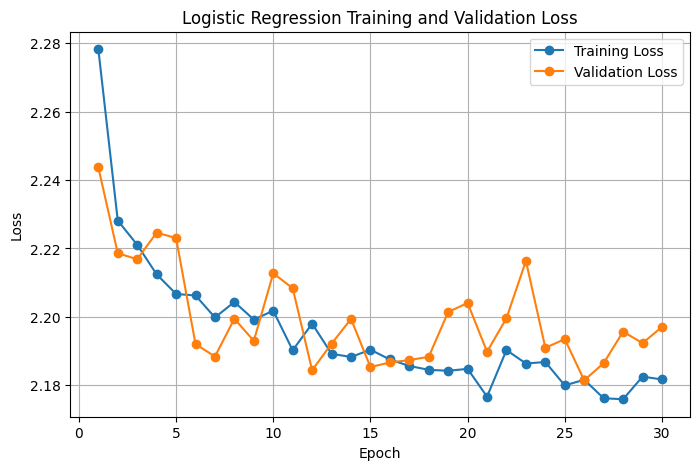

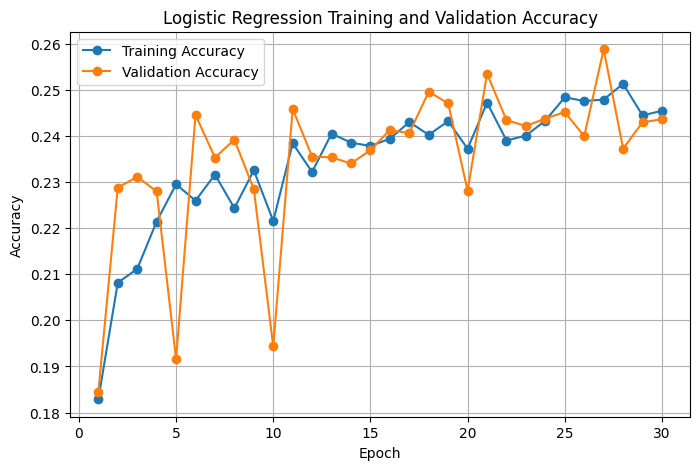

In [13]:
# ==============================
# 5. Plot Training Process
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Logistic Regression Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Training Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Logistic Regression Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Testing:   0%|          | 0/30 [00:00<?, ?it/s]

Final Test Accuracy
0.22942124345373976

Classification Report
              precision    recall  f1-score   support

           0       0.21      0.03      0.05      1004
           1       0.27      0.43      0.33      2844
           2       0.19      0.54      0.28      2210
           3       0.36      0.01      0.02      1707
           4       0.28      0.29      0.28      1497
           5       0.38      0.06      0.10      1390
           6       0.26      0.13      0.17      1156
           7       0.20      0.08      0.12      1142
           8       0.19      0.15      0.17      1006
           9       0.29      0.06      0.10       938

    accuracy                           0.23     14894
   macro avg       0.26      0.18      0.16     14894
weighted avg       0.27      0.23      0.19     14894



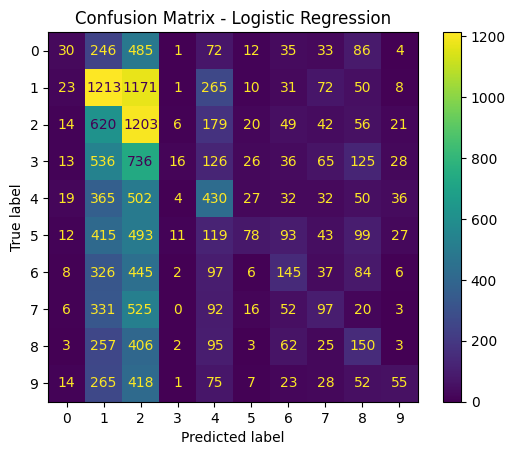

In [15]:
# ==============================
# 6. Final Test Evaluation
# ==============================

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Testing"):
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y_batch.cpu().numpy())

test_acc = accuracy_score(test_labels, test_preds)

print("==============================")
print("Final Test Accuracy")
print("==============================")
print(test_acc)

print("\n==============================")
print("Classification Report")
print("==============================")
print(classification_report(test_labels, test_preds))

ConfusionMatrixDisplay.from_predictions(test_labels, test_preds)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()